In [1]:
from jax import random
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import HMC, MCMC, MixedHMC, NUTS
import numpy as np
from scipy.stats import bernoulli, multivariate_normal, pearsonr, norm, multivariate_t, t
from scipy.stats import wasserstein_distance
from sklearn import feature_selection, preprocessing,linear_model
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from math import sqrt
from itertools import cycle
from metrics import absolute_covariance, mean_distance, DP_unfairness_WD, DP_unfairness_TV, individual_unfairness, penalisation_function, parity_gap

from projection import evaluate_posterior_per_budget, evaluate_conjugate_posterior, sample_projection_posterior, sample_posterior_with_projection_prior
from methods import fairlasso, evaluate_calders, standardlasso, evaluate_frrm, evaluate_fairfs
from generate_data import simulate_logreg, simulate_linreg
from scipy.stats import gaussian_kde
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.spatial import distance_matrix

import rpy2
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects import numpy2ri
#numpy2ri.activate()

In [2]:
# utils = importr('utils')
# utils.install_packages('fairml')
Fairml = importr("fairml")
plt.rcParams.update({'font.size': 14})

### Generate data

In [3]:
# data generation
data = simulate_logreg(n_train=500, n_test=500, rho=1.5, p=0.5, d=2, intercept=1.)
X_train, y_train, S_train, p_train = data["train"]
X_test, y_test, S_test, p_test = data["test"]

Dimension of design matrix: (1000, 8)


In [4]:
# feature unfairness
weights = np.abs(feature_selection.r_regression(X_train,S_train))
weights

array([0.00394281, 0.03039015, 0.0361306 , 0.0641219 , 0.60244896,
       0.60507461, 0.57100567, 0.57595862])

In [5]:
pen_truth = penalisation_function(data["beta"], weights)
pen_truth

2.7331564243466304

In [6]:
# corr and cov of (y,S)
feature_selection.r_regression(y_train.reshape(-1,1),S_train), np.cov(y_train.flatten(), S_train)[0,1]

(array([-0.40065652]), -0.09689378757515041)

In [7]:
np.sum(S_train==1),np.sum(S_train==0)

(245, 255)

(array([ 46.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 209.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

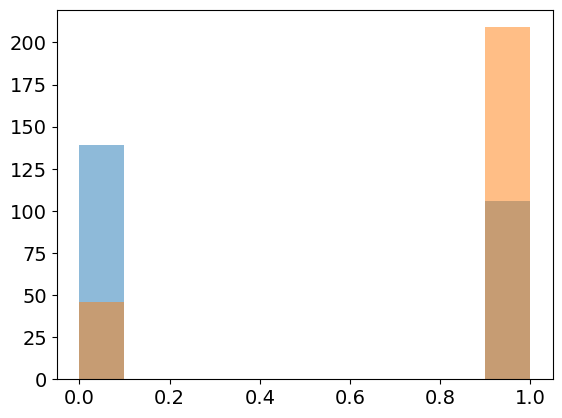

In [8]:
plt.hist(y_train[S_train==1], bins=10, alpha = 0.5)
plt.hist(y_train[S_train==0], bins=10, alpha = 0.5)

(array([ 13.,   8.,   9.,   4.,   4.,   7.,  17.,   9.,  25., 159.]),
 array([1.83919074e-04, 1.00165512e-01, 2.00147105e-01, 3.00128699e-01,
        4.00110292e-01, 5.00091885e-01, 6.00073478e-01, 7.00055071e-01,
        8.00036664e-01, 9.00018257e-01, 9.99999851e-01]),
 <BarContainer object of 10 artists>)

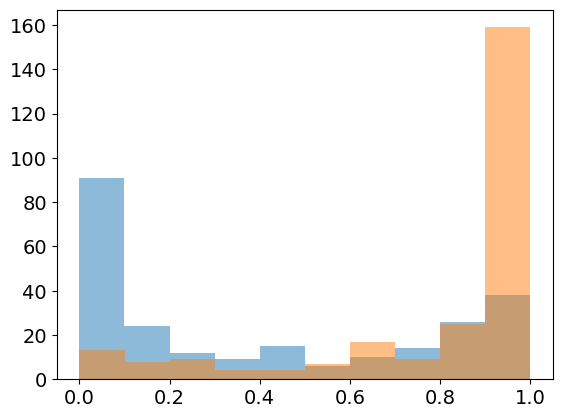

In [9]:
plt.hist(p_train[S_train==1], bins=10, alpha = 0.5)
plt.hist(p_train[S_train==0], bins=10, alpha = 0.5)

In [10]:
# parity gap
np.mean(y_train[S_train == 1]) - np.mean(y_train[S_train == 0])

-0.38695478191276506

In [11]:
parity_gap(y_train, S_train)

0.38695478191276506

### Fair Feature Selection

In [18]:
alphas = np.logspace(-1, 1., num=30, endpoint=True, base=10.0)
ffs_test = evaluate_fairfs(X_train, S_train, y_train, X_test, S_test, y_test, alphas=alphas, coeff=10.0, unfairness_metrics=["statistical_parity"],
                    p_train=p_train, p_val =p_test, coeff2 = 1.0)

statistical_parity | weight 0.1 | unfairness=0.394  log_loss=0.287  auc=0.949 | features: x0;x1;x2;x4;x5;x6;x7
statistical_parity | weight 0.11721022975334802 | unfairness=0.394  log_loss=0.287  auc=0.949 | features: x0;x1;x2;x4;x5;x6;x7
statistical_parity | weight 0.1373823795883263 | unfairness=0.394  log_loss=0.287  auc=0.949 | features: x0;x1;x2;x4;x5;x6;x7
statistical_parity | weight 0.16102620275609392 | unfairness=0.394  log_loss=0.287  auc=0.949 | features: x0;x1;x2;x4;x5;x6;x7
statistical_parity | weight 0.18873918221350972 | unfairness=0.394  log_loss=0.287  auc=0.949 | features: x0;x1;x2;x4;x5;x6;x7
statistical_parity | weight 0.2212216291070449 | unfairness=0.394  log_loss=0.287  auc=0.949 | features: x0;x1;x2;x4;x5;x6;x7
statistical_parity | weight 0.2592943797404667 | unfairness=0.394  log_loss=0.287  auc=0.949 | features: x0;x1;x2;x4;x5;x6;x7
statistical_parity | weight 0.30391953823131973 | unfairness=0.394  log_loss=0.287  auc=0.949 | features: x0;x1;x2;x4;x5;x6;x7
sta

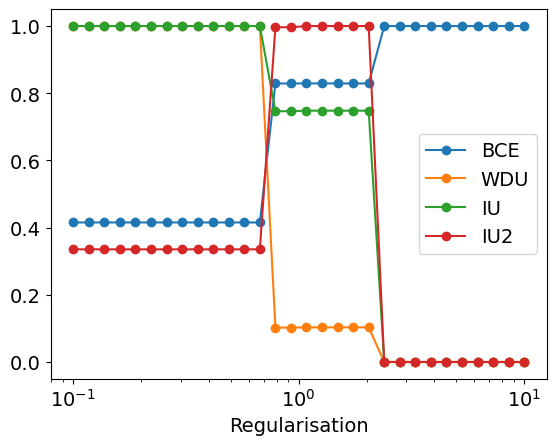

In [19]:
budget=ffs_test["alphas"]
for m in ["BCE", "WDU", "IU", "IU2"]:
    plt.plot(budget, ffs_test[m]/ max(ffs_test[m]), label=m, marker="o")
plt.xlabel("Regularisation")
plt.xscale("log")
plt.legend()

### FRRM : Fair classification with ridge penalty

In [20]:
budget = np.logspace(-2.5, 0., num=50, endpoint=True, base=10.0)
frrm_train, frrm_test = evaluate_frrm( X_train,  y_train, S_train, X_test, y_test, S_test, budget=budget, metric="correlation", task="class",
                                       p_train=p_train, p_val=p_test, coeff=10.0, coeff2=1.)

In [21]:
frrm_train["BCE"][-1]

0.2506541196081714

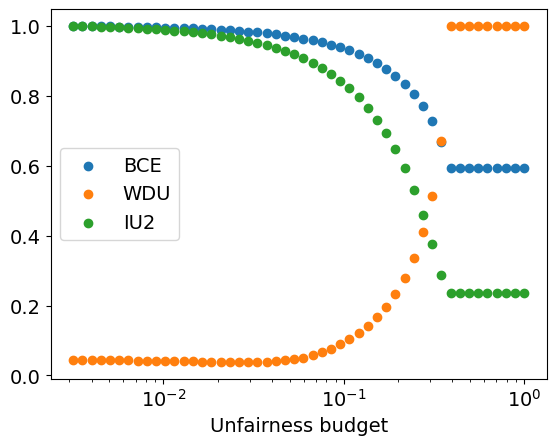

In [22]:
budget=frrm_train["budget"]
for m in ["BCE", "WDU", "IU2"]:
    plt.scatter(budget, frrm_train[m]/ max(frrm_train[m]), label=m)
plt.xlabel("Unfairness budget")
plt.xscale("log")
plt.legend()

### LASSO

In [23]:
C_values = np.logspace(-3, 3, num=100, endpoint=True, base=10.0)  # from strong to weak regularization
coefs = []
iu = []
for C in C_values:
    model = LogisticRegression(penalty="l1", C=1/C, solver="liblinear", fit_intercept=True, max_iter=10000, tol=1e-6)
    model.fit(X_train, y_train)
    coefs.append( np.insert(model.coef_[0],0, model.intercept_) )
    # probas = np.exp(model.predict_log_proba(X_train))[:,1]
    # fig, ax = plt.subplots()
    # ax.hist(probas[S_train==1], bins=10, alpha = 0.5)
    # ax.hist(probas[S_train==0], bins=10, alpha = 0.5)
    y_pred_train = np.exp(model.predict_log_proba(X_train))[:,1]
    iu.append(individual_unfairness(p_train, y_pred_train, S_train, task="reg", coeff=10.0))
coefs = np.array(coefs)
iu = np.array(iu)

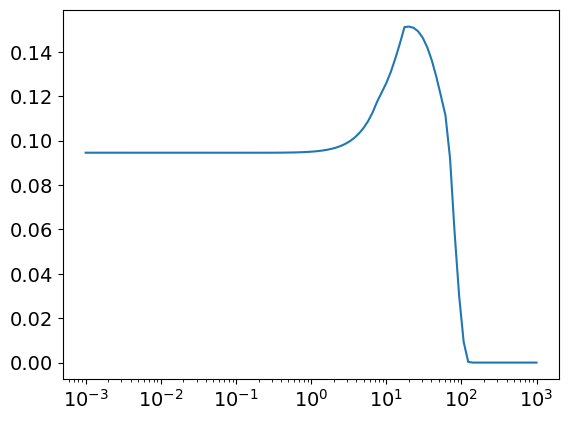

In [24]:
plt.plot(C_values, iu)
plt.xscale("log")

In [25]:
model.coef_[0], model.intercept_

(array([0., 0., 0., 0., 0., 0., 0., 0.]), array([0.]))

In [26]:
model.predict(X_train)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [27]:
y_pred_train = np.exp(model.predict_log_proba(X_train))[:,1]
y_pred_train

array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.

In [28]:
accuracy_score(y_train, y_pred_train > 0.5)

0.37

In [29]:
#individual_unfairness(y_train, y_pred_train, S_train, task="class")

In [30]:
#individual_unfairness(p_train, y_pred_train, S_train, task="reg", coeff=5.0)

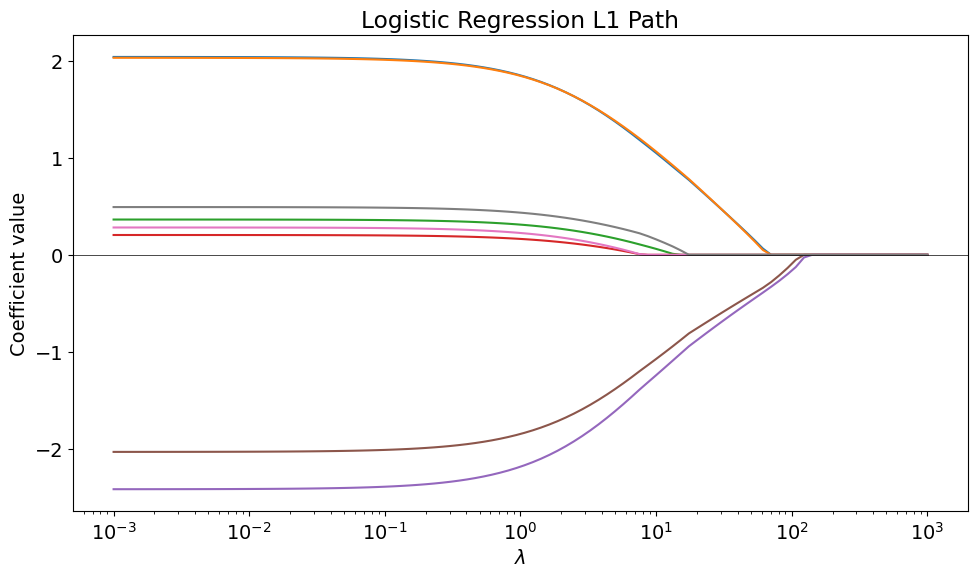

In [31]:
## Plot
plt.figure(figsize=(10, 6))
for i in range(1, coefs.shape[1]):
    #plt.plot( np.log10(C_values), coefs[:, i])
    plt.plot( C_values[::-1], coefs[:, i][::-1])
#plt.xlabel("log10(C)")
plt.xlabel(r"$\lambda$")
plt.ylabel("Coefficient value")
plt.title("Logistic Regression L1 Path")
plt.axhline(0, color="black", linewidth=0.5)
plt.xscale("log")
plt.tight_layout()
plt.show()

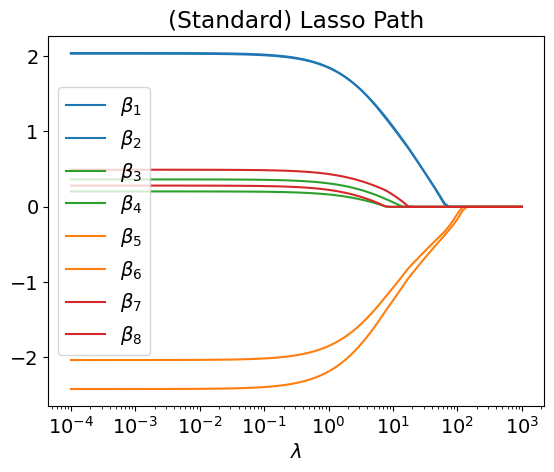

In [32]:
lasso = standardlasso()
alphas = np.logspace(-4, 3.0, num=100, endpoint=True, base=10.0)
lasso_results_train, lasso_results_test = lasso.evaluate(X_train, S_train, y_train, X_test, S_test, y_test, alphas= alphas, #alpha_path,
                                                                 metric="correlation", task="class", coeff=10.0, p_train=p_train, p_val=p_test, coeff2=1.0)

In [33]:
lasso_results_train["BCE"][0]

0.2506636614303985

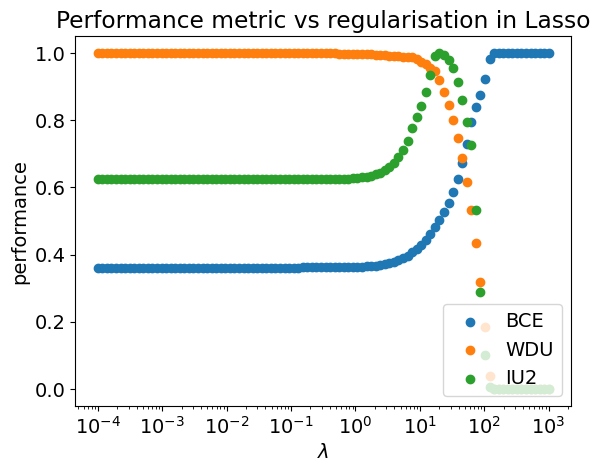

In [34]:
for m in ["BCE", "WDU", "IU2"]:
    plt.scatter(lasso_results_train["alphas"], lasso_results_train[m]/ max(lasso_results_train[m]), label=m)
#plt.scatter(lasso_results_train["alphas"], lasso_results_train["Correlation"] / max(lasso_results_train["Correlation"]), label="Correlation")
#plt.hlines(y=results_cald_val["mse"][0], xmin=lamda_grid[0], xmax=lamda_grid[-1])
#plt.yscale("log")
plt.title("Performance metric vs regularisation in Lasso")
plt.xlabel(r"$\lambda$")
plt.ylabel("performance")
plt.xscale("log")
plt.legend(loc="lower right")
plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/classification_lasso_class.pdf")

In [35]:
#lasso_results_train["IU"][0]

In [36]:
#lasso_results_train["weights"]

In [37]:
#lasso_results_train["CoeffPath"][-1]

### FAIR LASSO

In [12]:
weights = np.abs(feature_selection.r_regression(X_train, S_train))
W = np.diag(1.0 / weights)
X_star = X_train @ W

In [13]:
C_values = np.logspace(-3, 5, num=100, endpoint=True, base=10.0)  # from strong to weak regularization
coefs = []

for C in C_values:
    model = LogisticRegression(penalty="l1", C=1/C, solver="liblinear", fit_intercept=True, max_iter=10000, tol=1e-6)
    model.fit(X_star, y_train)
    coefs.append( np.insert(W * model.coef_[0],0, model.intercept_) )

coefs = np.array(coefs)

In [14]:
model.coef_

array([[0., 0., 0., 0., 0., 0., 0., 0.]])

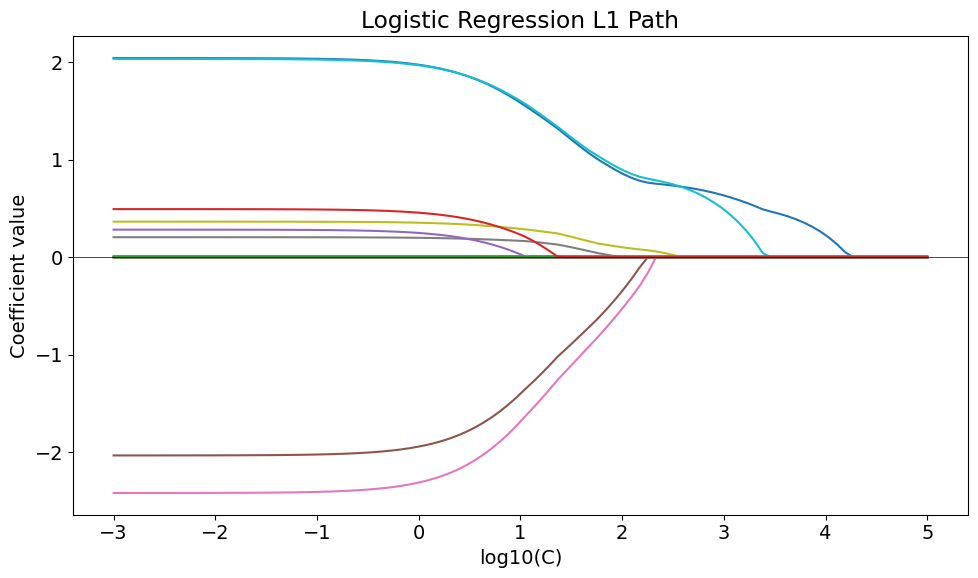

In [15]:
## Plot
plt.figure(figsize=(10, 6))
for i in range(1, coefs.shape[1]):
    plt.plot(np.log10(C_values), coefs[:, i])
plt.xlabel("log10(C)")
plt.ylabel("Coefficient value")
plt.title("Logistic Regression L1 Path")
plt.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

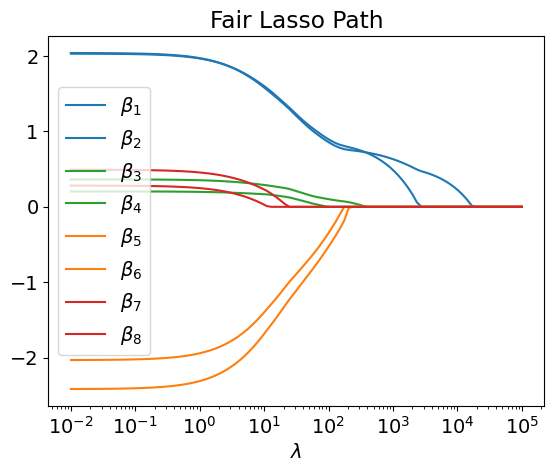

In [16]:
#alphas=np.linspace(0.01,30,200)
alphas_fair_lasso  = np.logspace( -2, 5, num=100, endpoint=True, base=10.0)
flasso = fairlasso()
results_train, results_test = flasso.evaluate(X_train, S_train, y_train, X_test, S_test, y_test, alphas=alphas_fair_lasso, metric='correlation', task = "class", coeff=10.0, p_train=p_train, p_val=p_test)

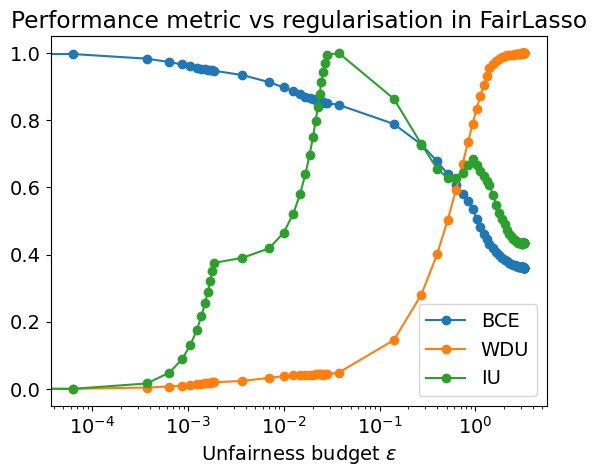

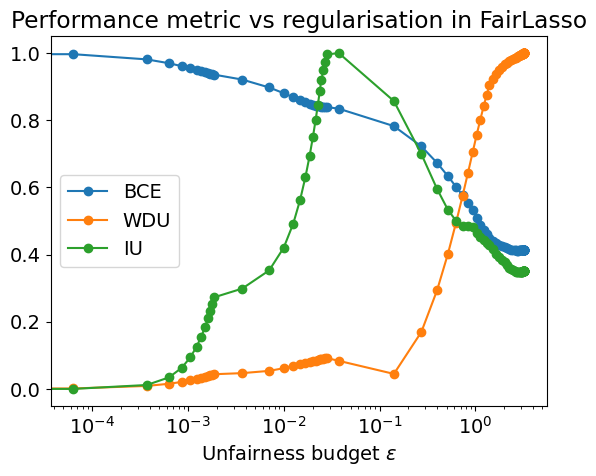

In [17]:
t = ["train", "test"]
for i,results in enumerate([results_train, results_test]):
    fig, ax = plt.subplots()
    for m in ["BCE", "WDU", "IU2"]:
        if m=="IU2":
            ax.plot(results["budget"], results[m] / max(results[m]), label="IU", marker="o")
        else:
            ax.plot(results["budget"], results[m] / max(results[m]), label=m, marker="o")
    # plt.scatter(results_train["alphas"], results_train["mse"]/ max(results_train["mse"]), label="MSE")
    # plt.scatter(results_train["alphas"], results_train["WDunfair"] /  max(results_train["WDunfair"]), label="DP-WD")
    # plt.scatter(results_train["alphas"], results_train["Indiv"] / max(results_train["Indiv"]), label="Indiv")
    #plt.scatter(results_train["alphas"], results_train["Correlation"], label="Correlation")
    #plt.scatter(results_train["alphas"], results_train["Pen"], label="Penalisation")
    #plt.hlines(y=results_cald_val["mse"][0], xmin=lamda_grid[0], xmax=lamda_grid[-1])
    plt.title("Performance metric vs regularisation in FairLasso")
    plt.xlabel(r"Unfairness budget $\epsilon$")
    #plt.ylabel("performance")
    plt.xscale("log")
    plt.legend()
    plt.savefig(f"/Users/deborah/PycharmProjects/FairModelSelection/figures/classification_fairlasso_{t[i]}.pdf")

In [79]:
# def pareto_plot(m1,m2, fair_lasso_results, lasso_results, frrm_results, fp_results = None, pp_results = None, sp_results = None, save_fig=None):
#
#     #max_1 = max( max(lasso_results[m1]), max(fair_lasso_results[m1]), max(frrm_results[m1]))
#     #max_2 = max( max(lasso_results[m2]), max(fair_lasso_results[m2]), max(frrm_results[m2]))
#     max_1, max_2 = 1.0,1.0
#
#     fig, ax = plt.subplots()
#     ax.scatter(  lasso_results[m1]/max_1, lasso_results[m2]/max_2, label="Lasso", marker="v")
#     ax.scatter( frrm_results[m1]/max_1,  frrm_results[m2]/max_2, label="FRRM", marker="^")
#     ax.scatter( fair_lasso_results[m1]/max_1,  fair_lasso_results[m2]/max_2, label="Fair Lasso")
#
#     if fp_results is not None:
#         avg_1 = np.mean(fp_results[m1], axis=1)
#         avg_2 = np.mean(fp_results[m2], axis=1)
#         ax.scatter(  avg_1 / max_1, avg_2 /max_2, label="PP")
#
#     if pp_results is not None:
#         avg_1 = np.mean(pp_results[m1], axis=1)
#         avg_2 = np.mean(pp_results[m2], axis=1)
#         ax.scatter(  avg_1 / max_1, avg_2 /max_2, label="PPP")
#
#     if sp_results is not None:
#         avg_1 = np.mean(sp_results[m1], axis=1)
#         avg_2 = np.mean(sp_results[m2], axis=1)
#         ax.scatter(  avg_1 / max_1, avg_2 /max_2, label="SP")
#
#     #plt.yscale("log")
#     plt.xlabel(m1)
#     plt.ylabel(m2)
#     plt.legend()
#     if save_fig is not None:
#         plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/" + save_fig)


In [38]:
def pareto_plot(m1,m2, fair_lasso_results, lasso_results, frrm_results = None, ffs_results = None, cald_results = None, fp_results = None, pp_results = None, sp_results = None, save_fig=None, normalise = False):

    if normalise:
        max_1 = max( max(lasso_results[m1]), max(fair_lasso_results[m1]), max(frrm_results[m1]))
        max_2 = max( max(lasso_results[m2]), max(fair_lasso_results[m2]), max(frrm_results[m2]))
    else:
        max_1, max_2 = 1.0,1.0

    fig, ax = plt.subplots()
    ax.plot(  lasso_results[m1]/max_1, lasso_results[m2]/max_2, label="Lasso", marker = "o", color="k", ms=10)

    ax.plot( fair_lasso_results[m1]/max_1,  fair_lasso_results[m2]/max_2, label="Fair Lasso", marker = "o", color='tab:blue', ms=10)

    if cald_results is not None:
        ax.plot(  cald_results[m1]/max_1, cald_results[m2]/max_2, label="MD", marker = "o", color="tab:orange")

    if frrm_results is not None:
        ax.plot( frrm_results[m1]/max_1,  frrm_results[m2]/max_2, label="FRRM", marker = "v", color="tab:red", ms=10)

    if ffs_results is not None:
        ax.plot( ffs_results[m1]/max_1,  ffs_results[m2]/max_2, label="FFS", marker = "v", color="tab:pink", ms=10)


    if fp_results is not None:
        avg_1 = np.mean(fp_results[m1], axis=1)
        avg_2 = np.mean(fp_results[m2], axis=1)
        ax.plot(  avg_1 / max_1, avg_2 /max_2, label="PP", marker="v", color='tab:brown')

    if pp_results is not None:
        avg_1 = np.mean(pp_results[m1], axis=1)
        avg_2 = np.mean(pp_results[m2], axis=1)
        ax.plot(  avg_1 / max_1, avg_2 /max_2, label="FP", marker = "P", color='tab:green')

    if sp_results is not None:
        avg_1 = np.mean(sp_results[m1], axis=1)
        avg_2 = np.mean(sp_results[m2], axis=1)
        ax.plot(  avg_1 / max_1, avg_2 /max_2, label="SP", marker = "v", color="k")

    #plt.yscale("log")
    if m1 == "IU2":
        plt.xlabel("IU")
    else:
        plt.xlabel(m1)
    if m2 == "IU2":
        plt.ylabel("IU")
    else:
        plt.ylabel(m2)
    plt.legend()
    if save_fig is not None:
        plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/" + save_fig)

In [39]:
results_train["CoeffPath"][-1], lasso_results_train["CoeffPath"][-1]

(array([0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0.]))

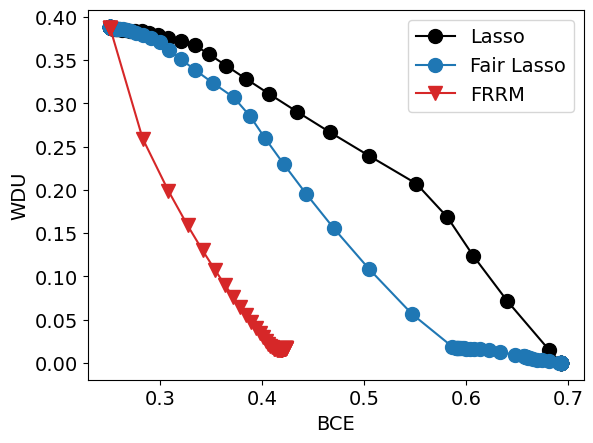

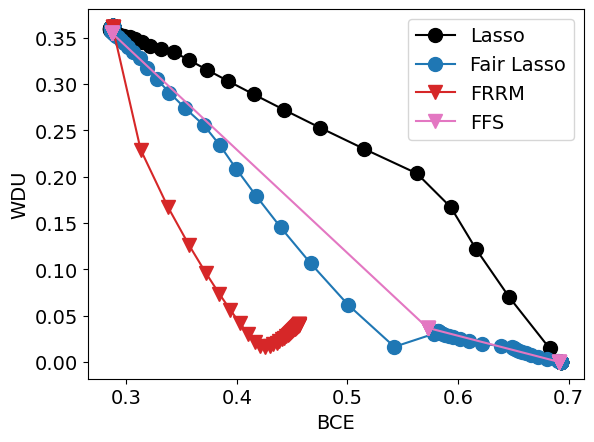

In [40]:
m2,m1 =  "WDU", "BCE"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, save_fig="class_comp_train_1")
pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, ffs_results=ffs_test, save_fig="class_comp_test_1")

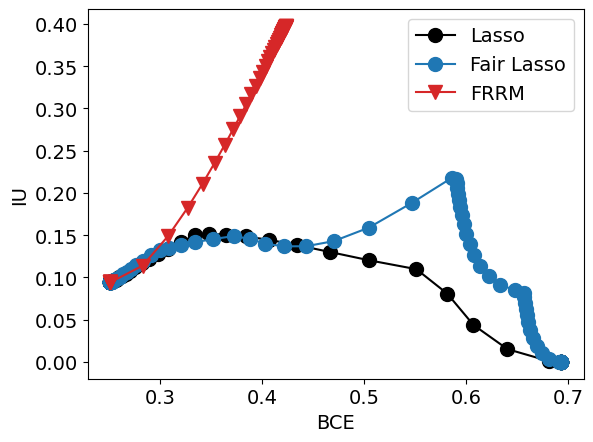

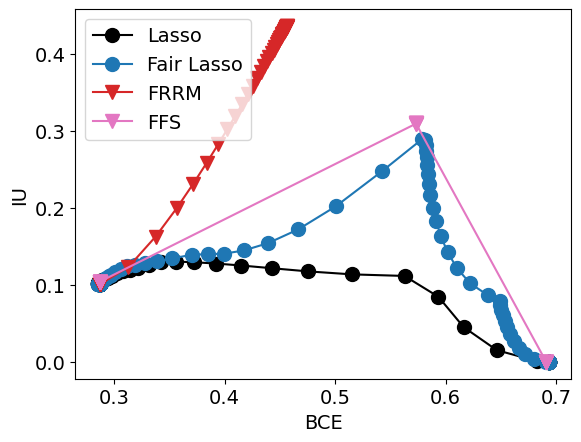

In [41]:
m2,m1 = "IU2", "BCE"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, save_fig="classification_comp_train_2")
pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, ffs_results=ffs_test, save_fig="classification_comp_test_2")

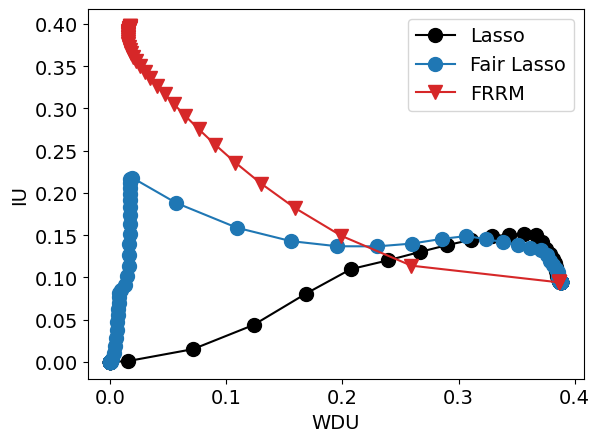

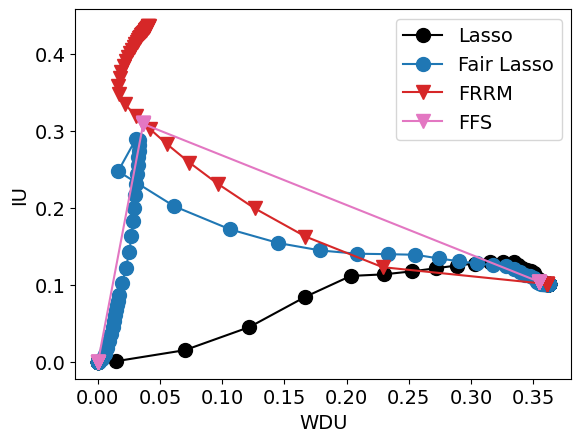

In [42]:
m1,m2 = "WDU", "IU2"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, save_fig="classification_comp_train_3")
pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, ffs_results=ffs_test, save_fig="classification_comp_test_3")

### Projected posterior and conjugate posterior

In [64]:
a, b = 1, 1 # hyperparameter of gamma prior
beta_var = 1.0
radius  = np.logspace(-4.0, 1.0, num=30, endpoint=True, base=10.0)
projection_post, conjugate_post = sample_projection_posterior(X_train, y_train, S_train, a=a, b=b, beta_var=beta_var, task="class", radius=radius, intercept=True, num_samples = 2000)

sample: 100%|██████████| 3000/3000 [00:02<00:00, 1491.49it/s, 7 steps of size 5.06e-01. acc. prob=0.90]


In [66]:
fp_results_train, fp_results_test = evaluate_posterior_per_budget(projection_post, X_train, S_train, y_train, X_test, S_test, y_test, task="class",
                                                                  p_train = p_train, p_val = p_test, coeff=10.0)
cp_results_train, cp_results_test = evaluate_conjugate_posterior(conjugate_post, X_train, S_train, y_train, X_test, S_test, y_test, task="class", weights=projection_post["weights"], p_train = p_train, p_val = p_test, coeff=10.0)

In [67]:
projection_post["samples"].shape

(30, 2000, 9)

In [68]:
# check posterior match for big alphas
projection_post["samples"][-1,0,:], conjugate_post["samples"][0,:]

(array([ 1.27523208,  1.6594857 ,  1.77220142,  0.48342779,  0.12815112,
        -2.30296898, -1.92876315,  0.52194339,  0.41776678]),
 Array([ 1.2752321 ,  1.6594857 ,  1.7722014 ,  0.4834278 ,  0.12815112,
        -2.302969  , -1.9287632 ,  0.5219434 ,  0.41776678], dtype=float32))

### Projected prior posterior and sparse posterior

In [69]:
proj_prior = sample_posterior_with_projection_prior(X_train, y_train, S_train, a=a, b=b, beta_var=beta_var, radius=radius, intercept=True, num_samples = 2000, task = "class",  metric = "correlation")

sample: 100%|██████████| 3000/3000 [00:01<00:00, 2138.24it/s, 7 steps of size 4.74e-01. acc. prob=0.91] 


In [70]:
radius  = np.logspace(-2.5, 1.5, num=30, endpoint=True, base=10.0)
sparse_prior = sample_posterior_with_projection_prior(X_train, y_train, S_train, a=a, b=b, beta_var=beta_var, radius=radius, intercept=True, num_samples = 1000, task = "class", metric = None)

sample: 100%|██████████| 2000/2000 [00:01<00:00, 1606.95it/s, 7 steps of size 4.74e-01. acc. prob=0.91] 


In [71]:
pp_results_train,pp_results_test = evaluate_posterior_per_budget(proj_prior, X_train, S_train, y_train, X_test, S_test, y_test, task = "class",
                                                                 p_train = p_train, p_val = p_test, coeff=10.0)
sp_results_train,sp_results_test = evaluate_posterior_per_budget(sparse_prior, X_train, S_train, y_train, X_test, S_test, y_test, task = "class",
                                                                 p_train = p_train, p_val = p_test, coeff=10.0)

In [72]:
weights = np.abs(feature_selection.r_regression(X_train,S_train))
pen_truth = penalisation_function(data["beta"], weights)

In [73]:
def posterior_risk_plot(fp_results, cp_results, savefig = None):

    colors = ["C0", "C1", "C2"]

    plt.figure(figsize=(8, 5))

    for i,m in enumerate(["BCE","WDU",  "IU2"]):

        lower = np.percentile(fp_results[m], 2.5, axis=1)
        upper = np.percentile(fp_results[m], 97.5, axis=1)
        median = np.percentile(fp_results[m], 50, axis=1)
        avg = np.mean(fp_results[m], axis=1)

        cp_mean_value = max( np.max(fp_results[m]), np.max(cp_results[m]))
        #cp_mean_value = 1.0
        #cp_mean_value = cp_results_train["pmean"][i]

        plt.fill_between(
            fp_results["budget"] / pen_truth,
            lower / cp_mean_value,
            upper / cp_mean_value,
            alpha=0.3,
            color=colors[i]
        )
        if m=="IU2":
            plt.plot(fp_results["budget"] / pen_truth, avg / cp_mean_value, label="IU", linewidth=2, color=colors[i])
        else:
            plt.plot(fp_results["budget"] / pen_truth, avg / cp_mean_value, label=m, linewidth=2, color=colors[i])

        lower = np.percentile(cp_results[m], 2.5)
        upper = np.percentile(cp_results[m], 97.5)
        plt.fill_between(
            fp_results["budget"] / pen_truth,
            lower  / cp_mean_value * np.ones(len(fp_results["budget"])),
            upper / cp_mean_value * np.ones(len(fp_results["budget"])),
            alpha=0.2,
            color=colors[i]
        )
        plt.hlines(y= np.mean(cp_results[m]) / cp_mean_value, xmin=0.00, xmax=max(fp_results_train["budget"]) / pen_truth, linestyles="dotted", color=colors[i])

    plt.xlabel("Unfairness budget")
    plt.ylabel("Metric")
    plt.xscale("log")
    plt.legend()
    if savefig is not None:
        plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/" + savefig)

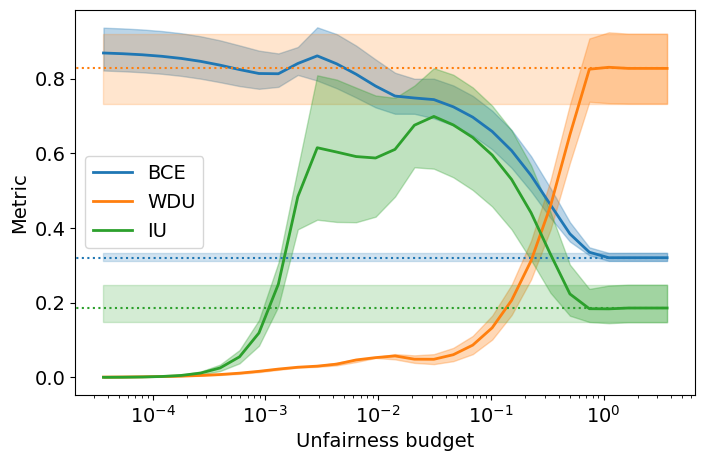

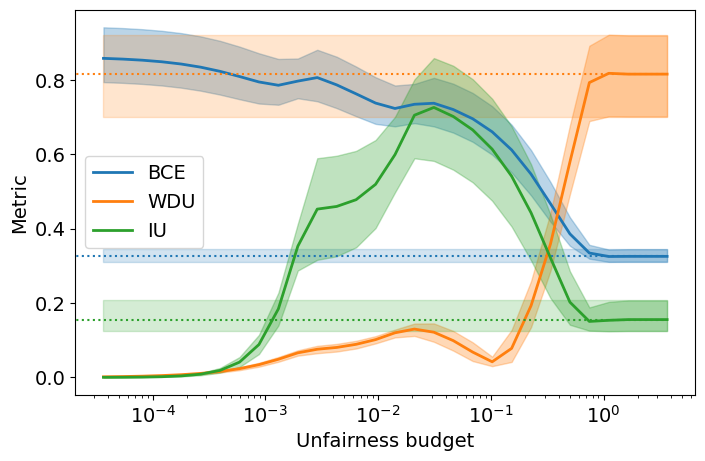

In [74]:
posterior_risk_plot(fp_results_train, cp_results_train, savefig = "classification_pp_train")
posterior_risk_plot(fp_results_test, cp_results_test, savefig = "classification_pp_test")

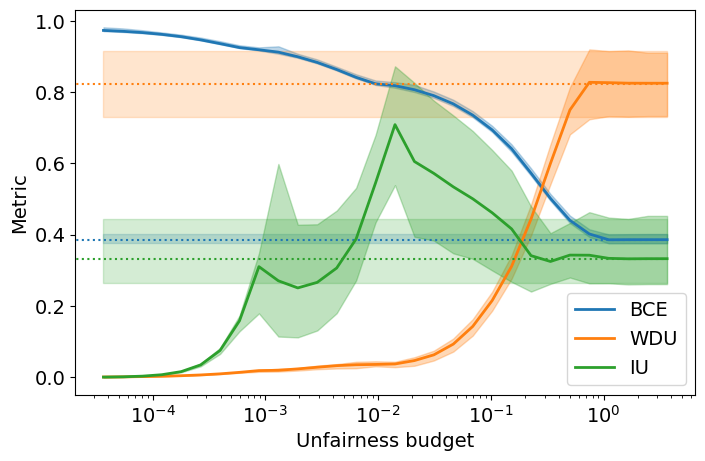

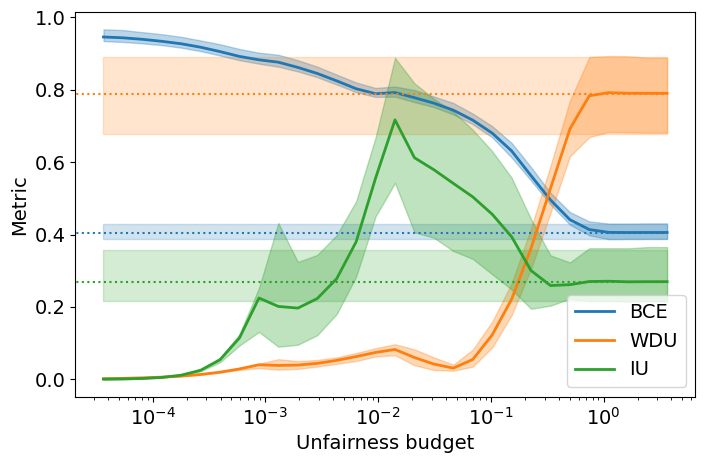

In [75]:
posterior_risk_plot(pp_results_train, cp_results_train, savefig = "classification_ppp_train")
posterior_risk_plot(pp_results_test, cp_results_test, savefig = "classification_ppp_test")

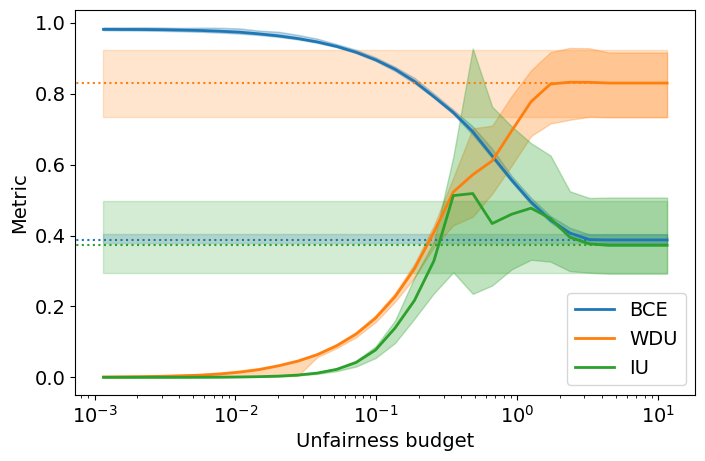

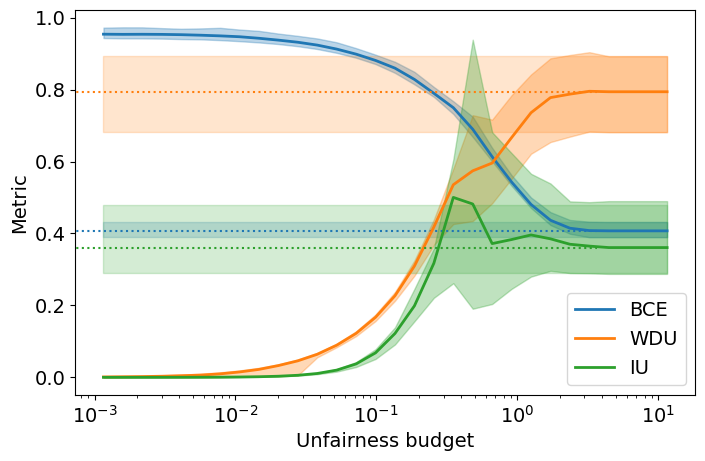

In [76]:
posterior_risk_plot(sp_results_train, cp_results_train, savefig = "classification_sp_train")
posterior_risk_plot(sp_results_test, cp_results_test, savefig = "classification_sp_test")

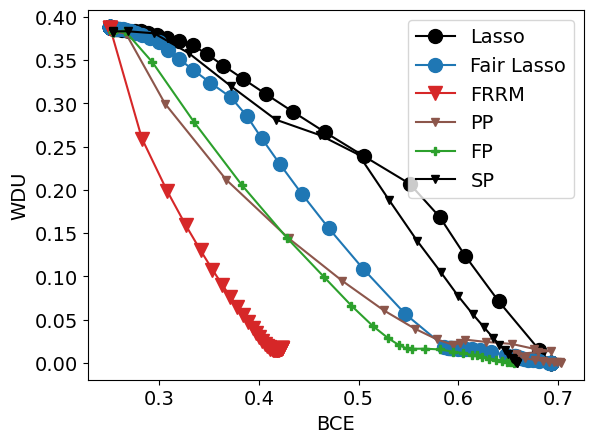

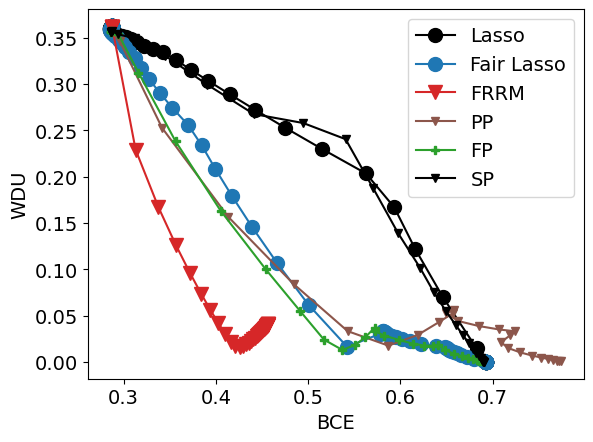

In [77]:
for results in [fp_results_train, fp_results_test, pp_results_train, pp_results_test, sp_results_train, sp_results_test]:
    for key in results["PP"]:
        results["PP"][key] = np.array(results["PP"][key]).reshape(-1,1)

m2,m1 = "WDU", "BCE"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, fp_results=fp_results_train["PP"], pp_results=pp_results_train["PP"], sp_results=sp_results_train["PP"], save_fig="classification_comp_all_train_1")
pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, fp_results=fp_results_test["PP"], pp_results=pp_results_test["PP"], sp_results=sp_results_test["PP"], save_fig="classification_comp_all_test_1")

In [78]:
# m2,m1 = "WDU", "BCE"
# pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, fp_results=fp_results_train, pp_results=pp_results_train, sp_results=sp_results_train, save_fig="classification_comp_all_train_1")
# pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, fp_results=fp_results_test, pp_results=pp_results_test, sp_results=sp_results_test, save_fig="classification_comp_all_test_1")

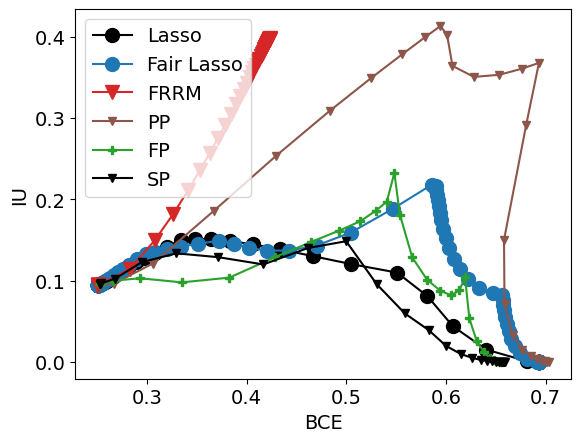

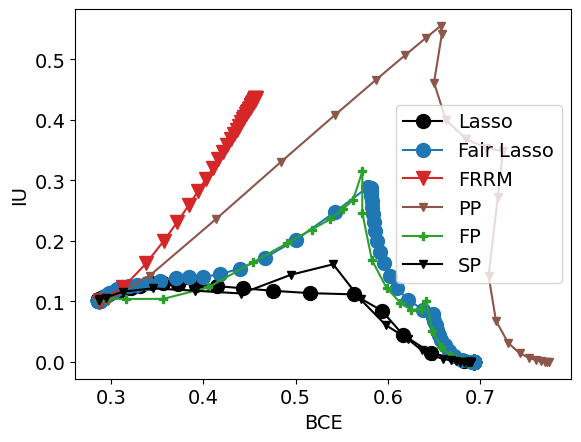

In [79]:
m2,m1 = "IU2", "BCE"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, fp_results=fp_results_train["PP"], pp_results=pp_results_train["PP"],  sp_results=sp_results_train["PP"], save_fig="classification_comp_all_train_2")
pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, fp_results=fp_results_test["PP"], pp_results=pp_results_test["PP"],  sp_results=sp_results_test["PP"], save_fig="classification_comp_all_test_2")

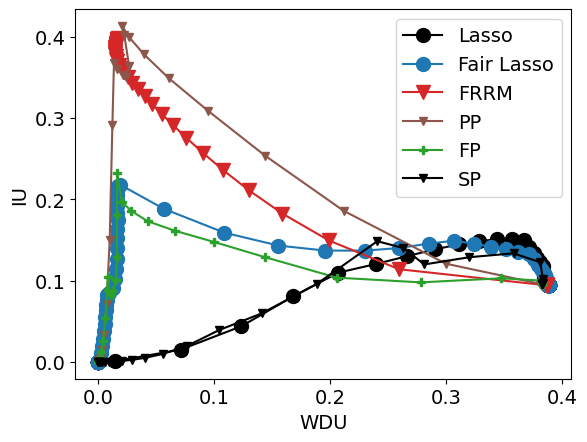

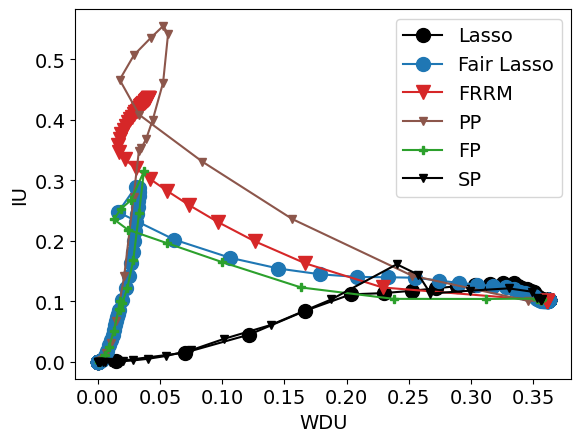

In [80]:
m1,m2 = "WDU", "IU2"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, fp_results=fp_results_train["PP"], pp_results=pp_results_train["PP"],  sp_results=sp_results_train["PP"],  save_fig="classification_comp_all_train_3")
pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, fp_results=fp_results_test["PP"], pp_results=pp_results_test["PP"],  sp_results=sp_results_test["PP"], save_fig="classification_comp_all_test_3")

Budget :  0.053026113359119845


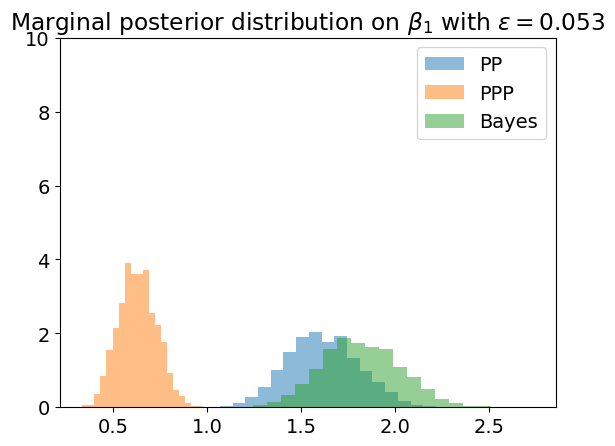

In [59]:
# Compare posterior : feature independent of S
idx = 15
j = 1 # feature
print("Budget : ", radius[idx])
plt.hist(projection_post["samples"][idx,:,j], alpha=0.5, label="PP", density=True, bins=20)
plt.hist(proj_prior["samples"][idx,:,j], alpha=0.5, label="PPP", density=True, bins=20)
plt.hist(conjugate_post["samples"][:,j], alpha=0.5, label="Bayes", density=True, bins=20)
#plt.hist(sparse_prior["samples"][idx,:,j], alpha=0.5, label="SP", density=True, bins=20)
plt.legend()
plt.ylim(0,10)
plt.title(rf"Marginal posterior distribution on $\beta_{j}$ with $\epsilon={radius[idx]:.3f}$")
plt.savefig(f"/Users/deborah/PycharmProjects/FairModelSelection/figures/classification_post_dist_f{j}_budget_{radius[idx]:.3f}.pdf")

Budget :  0.34738921120831157


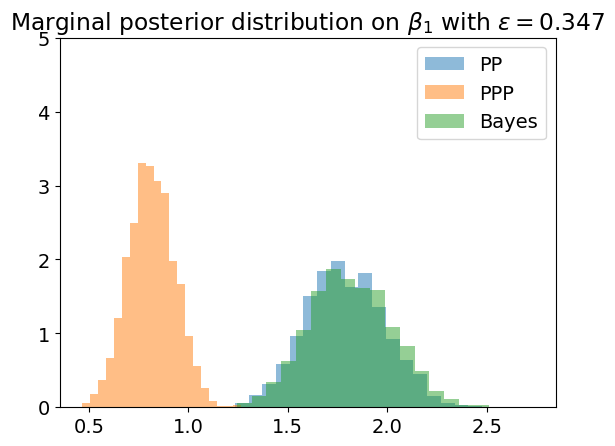

In [60]:
# Compare posterior : feature independent of S
idx = 25
j = 1 # feature
print("Budget : ", radius[idx])
plt.hist(projection_post["samples"][idx,:,j], alpha=0.5, label="PP", density=True, bins=20)
plt.hist(proj_prior["samples"][idx,:,j], alpha=0.5, label="PPP", density=True, bins=20)
plt.hist(conjugate_post["samples"][:,j], alpha=0.5, label="Bayes", density=True, bins=20)
plt.legend()
plt.ylim(0,5)
plt.title(rf"Marginal posterior distribution on $\beta_{j}$ with $\epsilon={radius[idx]:.3f}$")
plt.savefig(f"/Users/deborah/PycharmProjects/FairModelSelection/figures/classification_post_dist_f{j}_budget_{radius[idx]:.3f}.pdf")

Budget :  0.1357228782971653


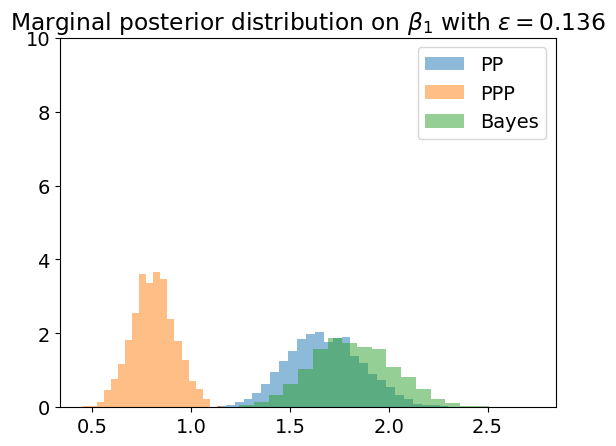

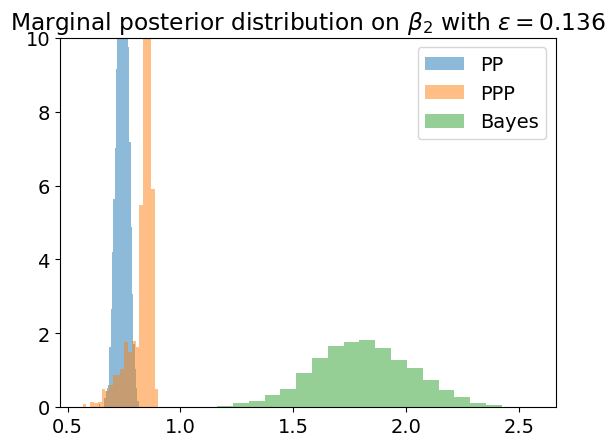

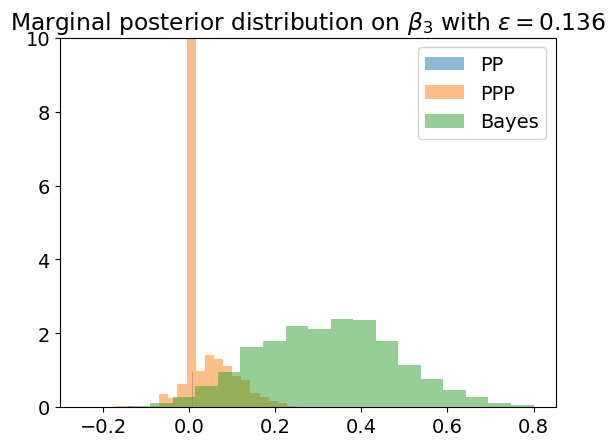

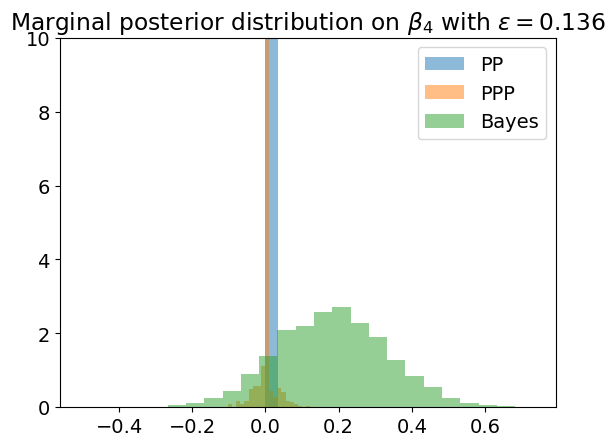

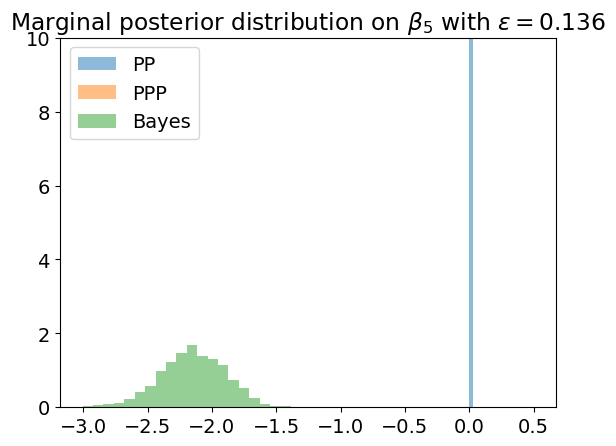

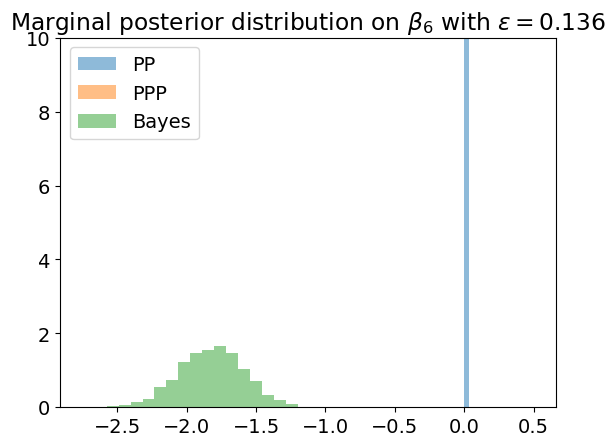

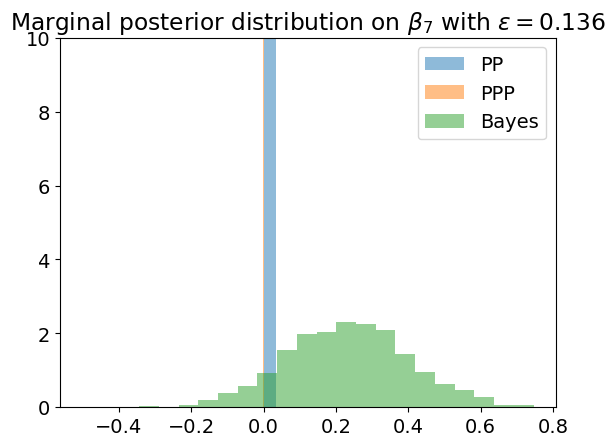

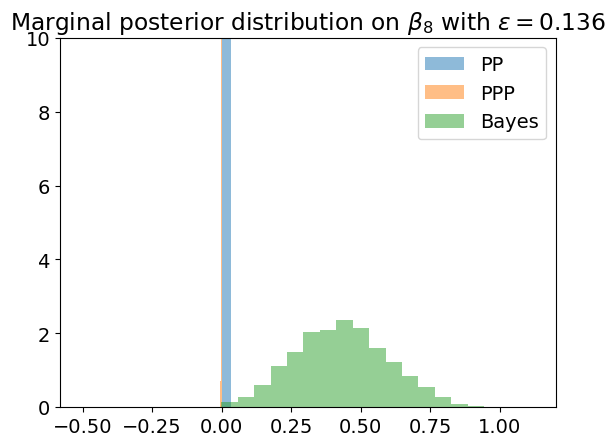

In [61]:
# Compare marginal posterior
idx = 20 # budget
j = 5 # feature
print("Budget : ", radius[idx])
for j in range(1, X_train.shape[1]+1):
    fig, ax = plt.subplots()
    ax.hist(projection_post["samples"][idx,:,j], alpha=0.5, label="PP", density=True, bins=30)
    ax.hist(proj_prior["samples"][idx,:,j], alpha=0.5, label="PPP", density=True, bins=20)
    ax.hist(conjugate_post["samples"][:,j], alpha=0.5, label="Bayes", density=True, bins=20)
    plt.legend()
    plt.ylim(0,10)
    plt.title(rf"Marginal posterior distribution on $\beta_{j}$ with $\epsilon={radius[idx]:.3f}$")
    plt.savefig(f"/Users/deborah/PycharmProjects/FairModelSelection/figures/classification_post_dist_f{j}_budget_{radius[idx]:.3f}.pdf")

Budget :  0.053026113359119845


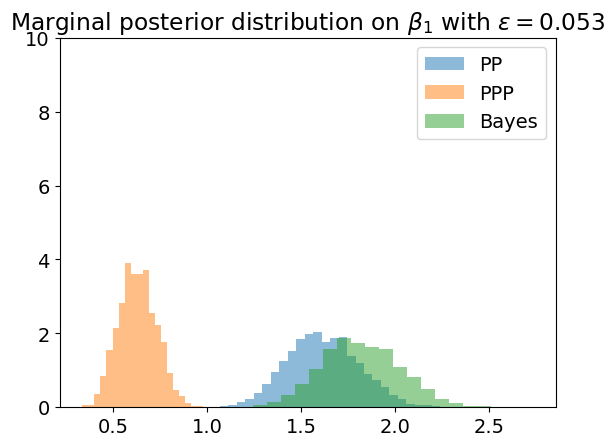

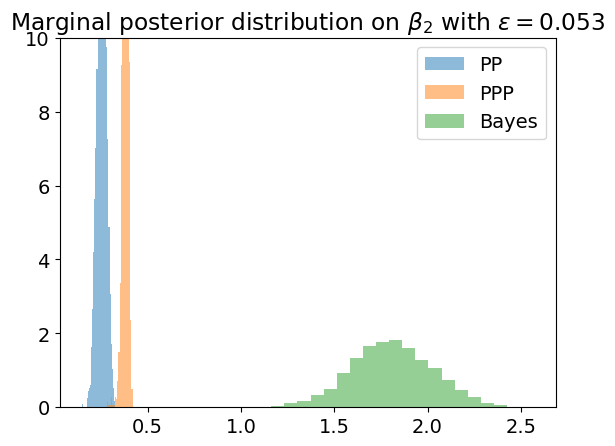

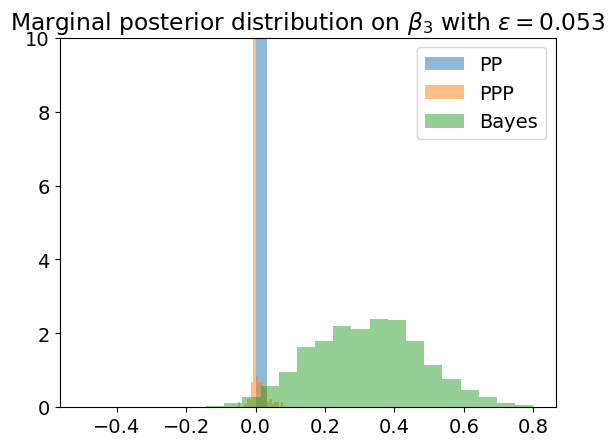

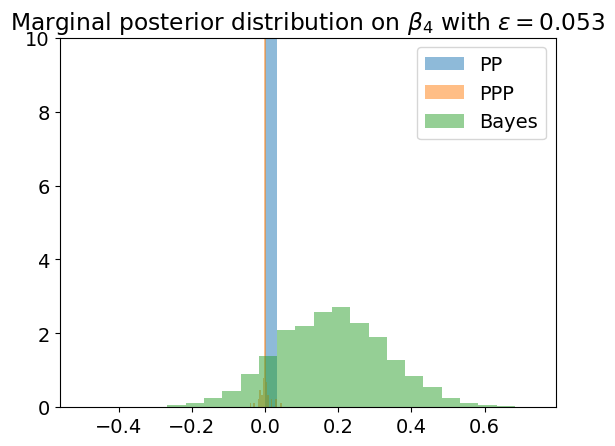

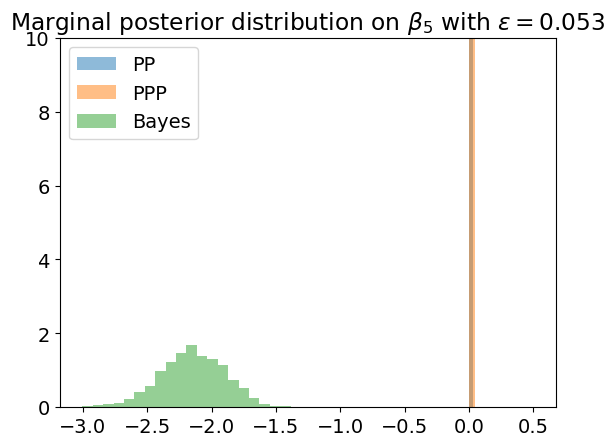

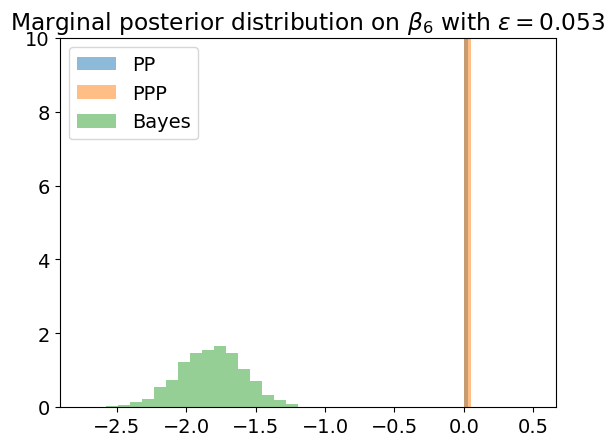

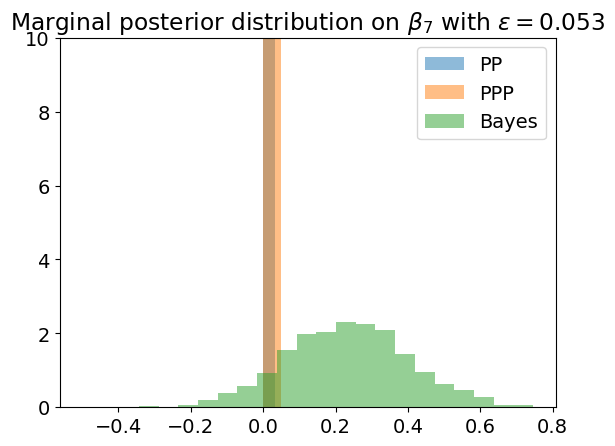

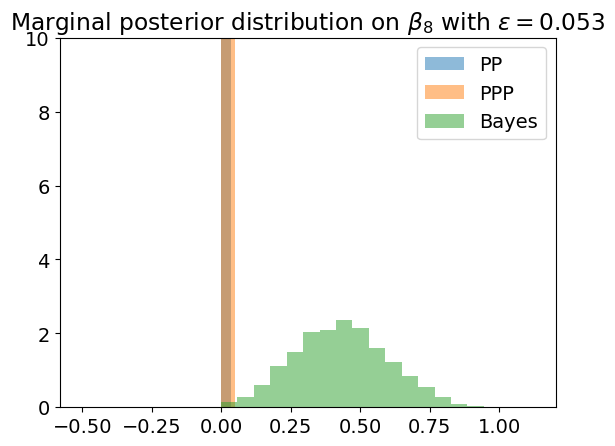

In [62]:
# Compare marginal posterior
idx = 15 # budget
j = 5 # feature
print("Budget : ", radius[idx])
for j in range(1, X_train.shape[1]+1):
    fig, ax = plt.subplots()
    ax.hist(projection_post["samples"][idx,:,j], alpha=0.5, label="PP", density=True, bins=30)
    ax.hist(proj_prior["samples"][idx,:,j], alpha=0.5, label="PPP", density=True, bins=20)
    ax.hist(conjugate_post["samples"][:,j], alpha=0.5, label="Bayes", density=True, bins=20)
    plt.legend()
    plt.ylim(0,10)
    plt.title(rf"Marginal posterior distribution on $\beta_{j}$ with $\epsilon={radius[idx]:.3f}$")
    plt.savefig(f"/Users/deborah/PycharmProjects/FairModelSelection/figures/classification_post_dist_f{j}_budget_{radius[idx]:.3f}.pdf")

Budget :  0.34738921120831157


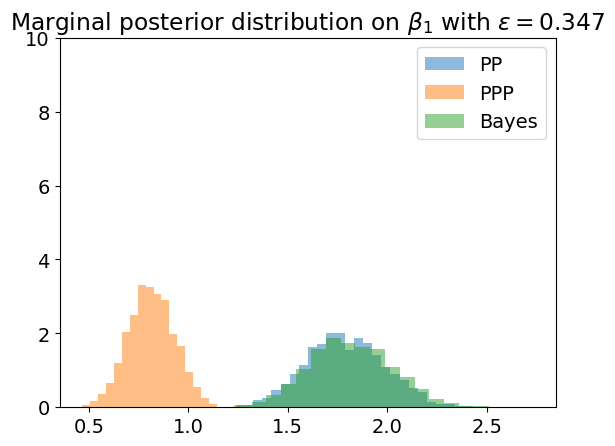

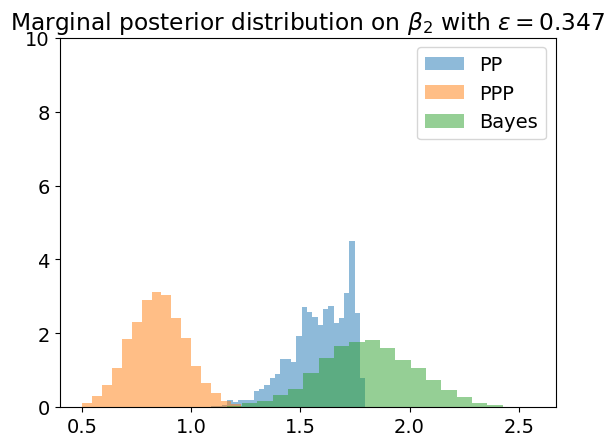

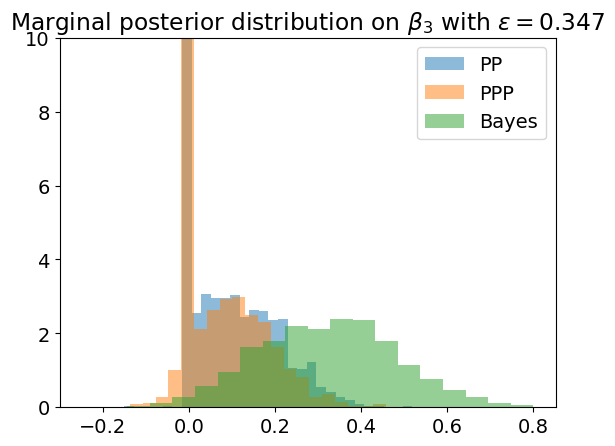

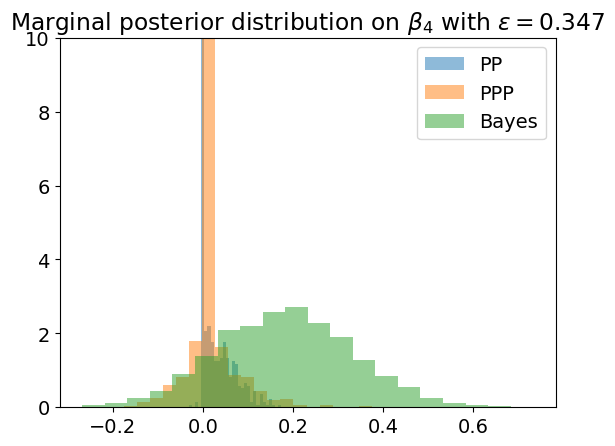

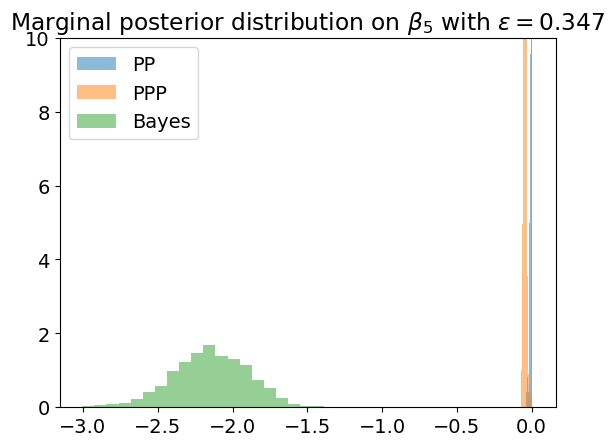

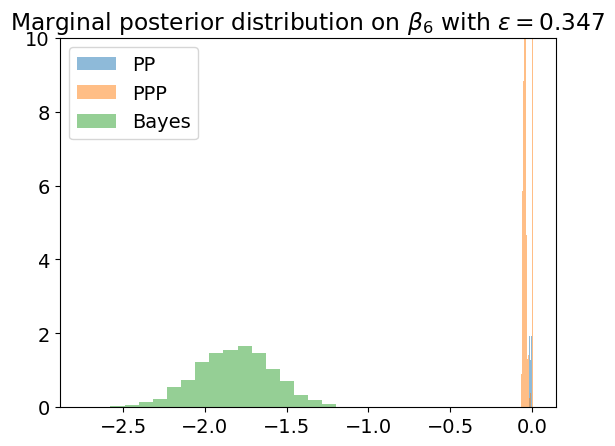

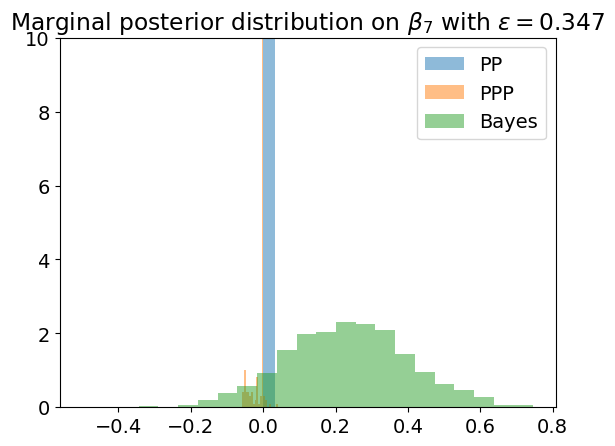

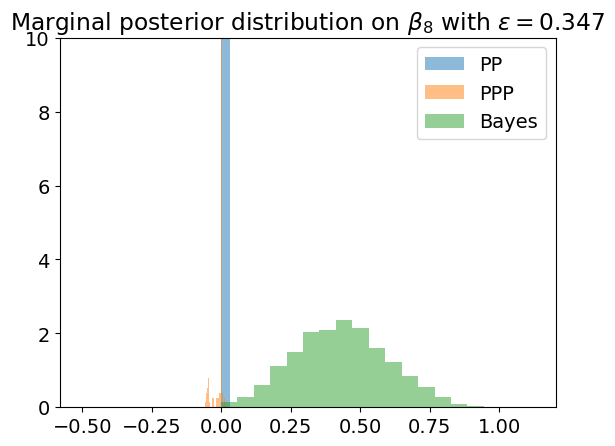

In [63]:
# Compare marginal posterior
idx = 25 # budget
j = 5 # feature
print("Budget : ", radius[idx])
for j in range(1, X_train.shape[1]+1):
    fig, ax = plt.subplots()
    ax.hist(projection_post["samples"][idx,:,j], alpha=0.5, label="PP", density=True, bins=30)
    ax.hist(proj_prior["samples"][idx,:,j], alpha=0.5, label="PPP", density=True, bins=20)
    ax.hist(conjugate_post["samples"][:,j], alpha=0.5, label="Bayes", density=True, bins=20)
    plt.legend()
    plt.ylim(0,10)
    plt.title(rf"Marginal posterior distribution on $\beta_{j}$ with $\epsilon={radius[idx]:.3f}$")
    plt.savefig(f"/Users/deborah/PycharmProjects/FairModelSelection/figures/classification_post_dist_f{j}_budget_{radius[idx]:.3f}.pdf")

In [ ]:
# plot posterior risk distribution

def get_hdr_levels(Z, masses):

    z = Z.ravel()

    z_sorted = np.sort(z)[::-1]

    cumsum = np.cumsum(z_sorted)

    cumsum /= cumsum[-1]

    levels = []

    for m in masses:

        idx = np.searchsorted(cumsum, m)

        levels.append(z_sorted[idx])

    levels = sorted(set(levels))

    return levels

def posterior_risk_2D_plot(results, m1, m2, idx1, idx2, idx3, savefig = None):

    # Grid
    x_grid = np.linspace(0, 1, 200)
    y_grid = np.linspace(0, 1, 200)

    max_1 = max( max(results[m1][idx1]), max(results[m1][idx2]), max(results[m1][idx3]) )
    max_2 = max( max(results[m2][idx1]), max(results[m2][idx2]), max(results[m2][idx3]) )
    #max_1, max_2 = 1.0, 1.0

    metrics1 = [pp_results_train[m1][idx1] / max_1, pp_results_train[m1][idx2] / max_1, pp_results_train[m1][idx3] / max_1]
    metrics2 = [pp_results_train[m2][idx1] / max_2, pp_results_train[m2][idx2] / max_2, pp_results_train[m2][idx3] / max_2]

    colors = ["tab:blue", "tab:orange", "tab:red"]
    labels = [results["budget"][idx1], results["budget"][idx2], results["budget"][idx3]]

    plt.figure()


    X, Y = np.meshgrid(x_grid, y_grid)
    positions = np.vstack([X.ravel(), Y.ravel()])


    for i in range(len(metrics1)):

        values = np.vstack([metrics1[i],metrics2[i]])
        kde = gaussian_kde(values)
        Z = kde(positions).reshape(X.shape)

        levels = get_hdr_levels(Z, masses=[0.50, 0.70, 0.9])
        #print(levels)

        plt.contour(X,Y,Z,levels=sorted(levels), colors=colors[i])

        plt.scatter(metrics1[i],metrics2[i],alpha=0.4,s=7, color=colors[i], label=rf"$\epsilon$={labels[i]:.2f}")

    plt.legend()
    plt.xlabel(m1)
    plt.ylabel(m2)
    plt.title("Fair Posterior risk")
    #plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/community_fairpost2_dist3.pdf")

    if savefig is not None:
        plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/" + savefig)

    plt.show()

In [ ]:
posterior_risk_2D_plot(fp_results_train, m1 = "logloss", m2="IU", idx1=20, idx2=25, idx3=-1, savefig="classification_pp_risk_mse_iu_train.pdf")
posterior_risk_2D_plot(fp_results_test, m1 = "logloss", m2="IU", idx1=20, idx2=25, idx3=-1, savefig="classification_pp_risk_mse_iu_test.pdf")

In [ ]:
posterior_risk_2D_plot(fp_results_train, m1 = "logloss", m2="Parity Gap", idx1=20, idx2=25, idx3=-1, savefig="classification_pp_risk_mse_wdu_train.pdf")
posterior_risk_2D_plot(fp_results_test, m1 = "logloss", m2="Parity Gap", idx1=20, idx2=25, idx3=-1, savefig="classification_pp_risk_mse_wdu_test.pdf")

In [ ]:
posterior_risk_2D_plot(pp_results_train, m1 = "logloss", m2="IU", idx1=20, idx2=25, idx3=-1,  savefig="classification_ppp_risk_mse_iu_train.pdf")
posterior_risk_2D_plot(pp_results_test, m1 = "logloss", m2="IU", idx1=20, idx2=25, idx3=-1,  savefig="classification_ppp_risk_mse_iu_test.pdf")

In [ ]:
posterior_risk_2D_plot(fp_results_train, m1 = "logloss", m2="Parity Gap", idx1=20, idx2=25, idx3=-1, savefig="classification_ppp_risk_mse_wdu_train.pdf")
posterior_risk_2D_plot(fp_results_test, m1 = "logloss", m2="Parity Gap", idx1=20, idx2=25, idx3=-1, savefig="classification_ppp_risk_mse_wdu_test.pdf")